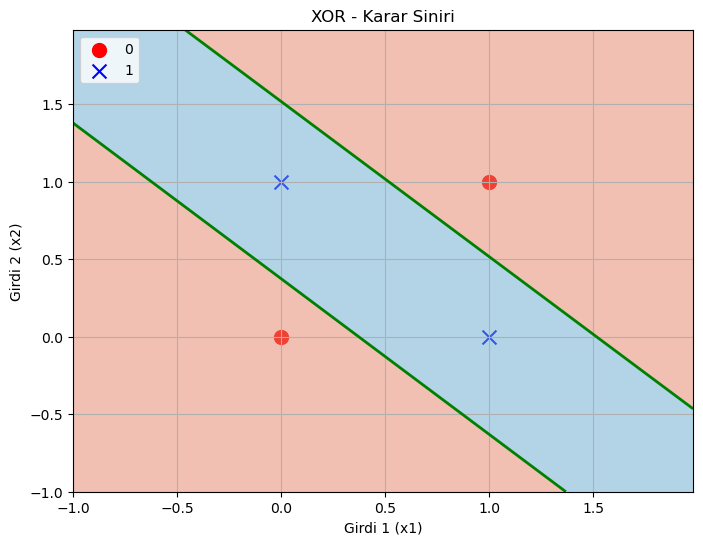

Tahminler (Ham):
[[0.04455843]
 [0.95052275]
 [0.95058338]
 [0.06278769]]

Tahminler (Yuvarlanmis):
[[0.]
 [1.]
 [1.]
 [0.]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

input_size = 2
hidden_size = 2
output_size = 1

w1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
w2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

lr = 0.01
epochs = 100000

for epoch in range(epochs):
    z1 = np.dot(X, w1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, w2) + b2
    y_pred = sigmoid(z2)

    error = y_pred - y

    delta2 = error * sigmoid_derivative(z2)
    dw2 = np.dot(a1.T, delta2)
    db2 = np.sum(delta2, axis=0, keepdims=True)

    delta1 = np.dot(delta2, w2.T) * sigmoid_derivative(z1)
    dw1 = np.dot(X.T, delta1)
    db1 = np.sum(delta1, axis=0, keepdims=True)

    w2 -= lr * dw2
    b2 -= lr * db2
    w1 -= lr * dw1
    b1 -= lr * db1

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(len(X)):
    if y[i] == 0:
        ax.scatter(X[i, 0], X[i, 1], color='red', marker='o', s=100, label='0' if i == 0 else "")
    else:
        ax.scatter(X[i, 0], X[i, 1], color='blue', marker='x', s=100, label='1' if i == 1 else "")

h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
z1_grid = np.dot(grid_points, w1) + b1
a1_grid = sigmoid(z1_grid)
z2_grid = np.dot(a1_grid, w2) + b2
pred_grid = sigmoid(z2_grid).reshape(xx.shape)

ax.contourf(xx, yy, pred_grid, levels=[0, 0.5, 1], cmap=plt.cm.RdBu, alpha=0.5)
ax.contour(xx, yy, pred_grid, levels=[0.5], colors='green', linewidths=2)
ax.set_xlabel('Girdi 1 (x1)')
ax.set_ylabel('Girdi 2 (x2)')
ax.set_title('XOR - Karar Sınırı')
ax.legend(loc='upper left')
ax.grid(True)
plt.show()

z1 = np.dot(X, w1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, w2) + b2
final_predictions = sigmoid(z2)

print("Tahminler (Ham):")
print(final_predictions)
print("\nTahminler (Yuvarlanmış):")
print(final_predictions.round())